# Speech Psychology — Baseline Model
**روش:** TF-IDF + Ridge Regression (Multi-output)

هدف: پیش‌بینی ۱۰ ویژگی روانشناختی برای هر متن، مقدار بین ۰ تا ۴

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
train = pd.read_csv('comments/train.csv')
test  = pd.read_csv('comments/test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head(3)

Train shape: (15786, 11)
Test shape:  (1754, 1)


,text,sense,honor,curse,despise,situation,antihuman,roughness,slaughter,strike_support,depression_rate
0,This is amazing! Kudos for that women for bein...,0.0,0.00,0.00,0.00,1.0,0.00,0.00,0.00,1.0,0.0
1,@IlhanMN Omar-you are a racist! Resign! And be...,4.0,3.67,3.33,2.67,3.0,1.33,1.33,0.67,3.0,0.0
2,I feel the same. El Paso made me a very open u...,1.0,1.50,0.50,0.50,2.0,1.50,0.50,0.50,1.5,0.0


## 3. Exploratory Data Analysis (EDA)

In [3]:
TARGET_COLS = [
    'sense', 'honor', 'curse', 'despise', 'situation',
    'antihuman', 'roughness', 'slaughter', 'strike_support', 'depression_rate'
]

# آمار توصیفی ستون‌های هدف
train[TARGET_COLS].describe().round(2)

,sense,honor,curse,despise,situation,antihuman,roughness,slaughter,strike_support,depression_rate
count,15786.00,15786.00,15786.00,15786.00,15786.00,15786.00,15786.00,15786.00,15786.00,15786.00
mean,2.58,2.40,2.10,1.80,2.41,1.40,0.68,0.43,2.31,0.32
std,1.10,1.12,1.18,1.10,0.66,1.02,0.91,0.77,0.88,0.56
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,2.00,1.00,1.00,2.00,0.50,0.00,0.00,2.00,0.00
50%,3.00,2.50,2.00,2.00,2.25,1.25,0.33,0.00,2.33,0.00
75%,3.50,3.25,3.00,2.67,3.00,2.00,1.00,0.50,3.00,0.50
max,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,2.00


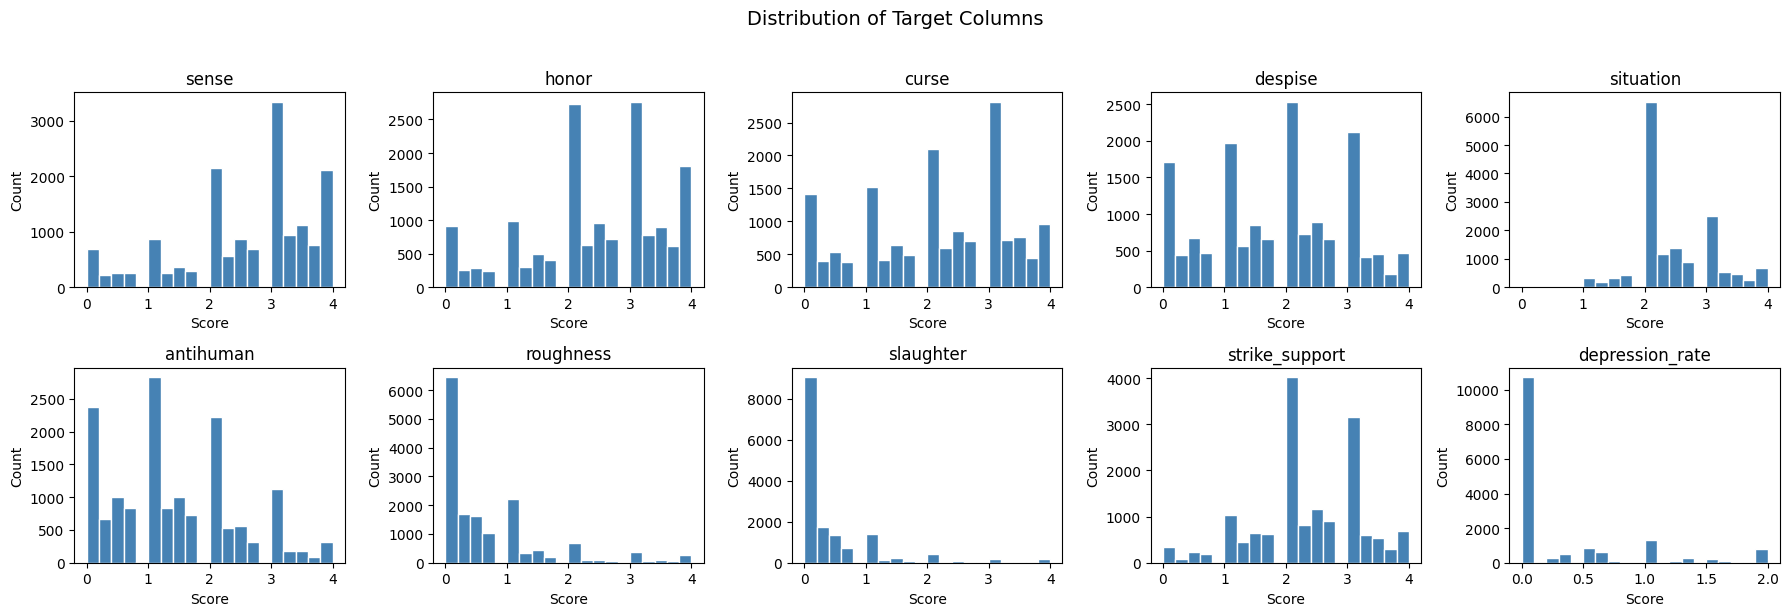

In [4]:
# توزیع هر ویژگی
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(TARGET_COLS):
    axes[i].hist(train[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Target Columns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# بررسی متون non-English
non_ascii = train['text'].apply(lambda x: any(ord(c) > 127 for c in str(x)))
print(f'تعداد متون non-ASCII: {non_ascii.sum()} از {len(train)}')

# نمونه
train[non_ascii]['text'].head(3).tolist()

تعداد متون non-ASCII: 1375 از 15786


['PROPHET MUHAMMAD PBUH SAID.❣ The strongest bond of faith is loyalty for the sake of Allah and opposition for His sake.🌹',
 'Please do more of Indian Ethnic Wear stripping, teasing and playing with yourself. The pink saree vid was unreal. Am sure you can add more heat to the hot Indian Ethnic Wear. Add some jewelry too (kamarbandh, nose rings, anklet, necklace). Lots of love ❤️',
 'And with this BCCI won a million hearts☺️😊😀😁.  I just love everything abt my country 😘😘 #BCCI  #BalidaanBadge  #BalidanBadge']

میانگین طول متن: 136 کاراکتر
حداکثر: 599 | حداقل: 7


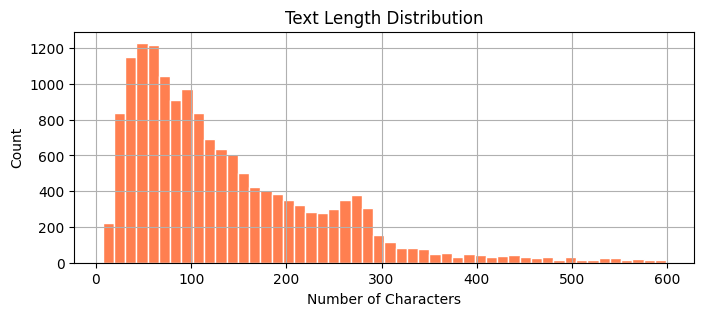

In [6]:
# طول متون
train['text_len'] = train['text'].fillna('').apply(len)
print(f"میانگین طول متن: {train['text_len'].mean():.0f} کاراکتر")
print(f"حداکثر: {train['text_len'].max()} | حداقل: {train['text_len'].min()}")

train['text_len'].hist(bins=50, figsize=(8,3), color='coral', edgecolor='white')
plt.title('Text Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('Count')
plt.show()

## 4. Preprocessing

In [7]:
# جدا کردن features و targets
X_train = train['text'].fillna('').astype(str)
y_train = train[TARGET_COLS]
X_test  = test['text'].fillna('').astype(str)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}')

X_train: (15786,), y_train: (15786, 10)
X_test:  (1754,)


## 5. TF-IDF Vectorization

TF-IDF هر کلمه را بر اساس فراوانی در متن و نادر بودن در کل corpus وزن‌دهی می‌کند.
- `ngram_range=(1,2)`: علاوه بر کلمات تکی، bigram هم در نظر می‌گیریم
- `sublinear_tf=True`: از log-scaling برای فراوانی استفاده می‌کنیم تا کلمات خیلی پرتکرار وزن کمتری بگیرند

In [8]:
tfidf = TfidfVectorizer(
    max_features=30000,    # حداکثر ۳۰ هزار feature
    ngram_range=(1, 2),    # unigram + bigram
    sublinear_tf=True,     # log(tf) به جای tf
    min_df=2,              # کلماتی که حداقل ۲ بار آمده‌اند
    strip_accents='unicode',
    analyzer='word'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF Train matrix: {X_train_tfidf.shape}')
print(f'TF-IDF Test matrix:  {X_test_tfidf.shape}')

TF-IDF Train matrix: (15786, 30000)
TF-IDF Test matrix:  (1754, 30000)


## 6. Model: Ridge Regression (Multi-Output)

Ridge Regression یه linear regression با L2 regularization است.
از `MultiOutputRegressor` استفاده می‌کنیم تا برای هر ۱۰ ستون جداگانه مدل بسازد.

In [9]:
# ساخت و آموزش مدل
model = MultiOutputRegressor(
    Ridge(alpha=1.0),   # alpha: میزان regularization
    n_jobs=-1           # استفاده از همه CPU cores
)

model.fit(X_train_tfidf, y_train)
print('مدل آموزش دید!')

مدل آموزش دید!


## 7. Evaluation — Cross Validation

In [10]:
# محاسبه RMSE برای هر ستون با 5-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = {}

for col in TARGET_COLS:
    scores = cross_val_score(
        Ridge(alpha=1.0),
        X_train_tfidf,
        y_train[col],
        cv=kf,
        scoring='neg_root_mean_squared_error'
    )
    rmse_scores[col] = -scores.mean()

# نمایش نتایج
results_df = pd.DataFrame({'Column': list(rmse_scores.keys()),
                            'RMSE':   list(rmse_scores.values())})
results_df = results_df.sort_values('RMSE', ascending=False)

print(results_df.to_string(index=False))

mcrmse = results_df['RMSE'].mean()
score  = (1.5 - mcrmse) * (100/150) * 150
print(f'\nMCRMSE: {mcrmse:.4f}')
print(f'Estimated Score: {score:.2f} / 150')

         Column     RMSE
          curse 0.937108
        despise 0.913926
      antihuman 0.911127
          honor 0.866869
          sense 0.823185
      roughness 0.771863
 strike_support 0.749926
      slaughter 0.667197
      situation 0.592320
depression_rate 0.512150

MCRMSE: 0.7746
Estimated Score: 72.54 / 150


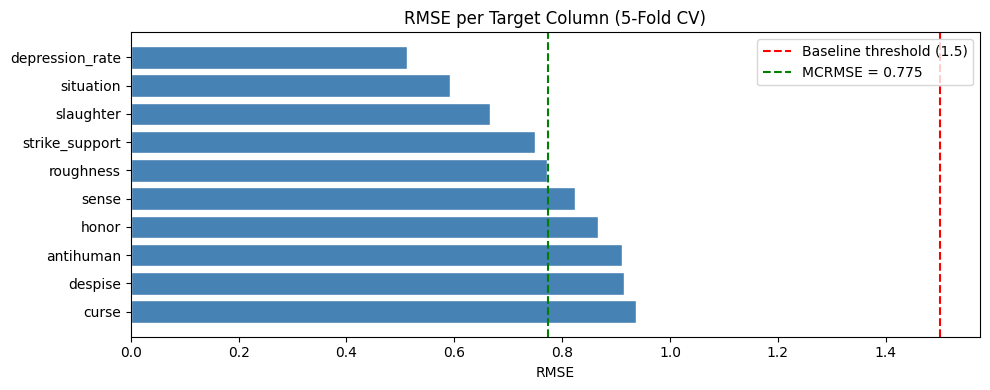

In [11]:
# نمودار RMSE هر ستون
plt.figure(figsize=(10, 4))
bars = plt.barh(results_df['Column'], results_df['RMSE'], color='steelblue', edgecolor='white')
plt.axvline(x=1.5, color='red', linestyle='--', label='Baseline threshold (1.5)')
plt.axvline(x=mcrmse, color='green', linestyle='--', label=f'MCRMSE = {mcrmse:.3f}')
plt.xlabel('RMSE')
plt.title('RMSE per Target Column (5-Fold CV)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Predict on Test Set

In [12]:
# پیش‌بینی روی test
preds = model.predict(X_test_tfidf)

# clip: مقادیر خارج از بازه [0, 4] رو برش می‌زنیم
preds = np.clip(preds, 0, 4)

# ذخیره در DataFrame
output = pd.DataFrame(preds, columns=TARGET_COLS).round(3)

print(f'Output shape: {output.shape}')
output.head()

Output shape: (1754, 10)


,sense,honor,curse,despise,situation,antihuman,roughness,slaughter,strike_support,depression_rate
0,3.287,3.573,3.337,2.876,2.865,2.200,0.785,0.725,2.950,0.643
1,2.564,2.606,2.210,1.902,2.343,1.231,1.113,0.687,2.446,0.076
2,2.421,2.640,2.319,2.195,2.212,1.879,0.487,0.135,2.081,0.178
3,3.324,3.323,2.893,1.965,2.697,1.542,0.652,0.552,3.163,0.499
4,2.670,2.329,2.228,1.907,2.244,1.414,0.897,0.615,2.159,0.280


## 9. Save Output

In [13]:
output.to_csv('baseline_output.csv', index=False)
print(f'baseline_output.csv ذخیره شد — {len(output)} سطر، {len(output.columns)} ستون')

baseline_output.csv ذخیره شد — 1754 سطر، 10 ستون


## 10. Summary

| مرحله | روش |
|-------|-----|
| Vectorization | TF-IDF (unigram + bigram, 30K features) |
| Model | Ridge Regression (Multi-Output) |
| Evaluation | 5-Fold Cross Validation — MCRMSE |

**نقاط ضعف این baseline:**
- معنای جمله رو درک نمی‌کند (فقط کلمات رو می‌بیند)
- متون غیرانگلیسی رو به درستی handle نمی‌کند
- ترتیب کلمات برایش مهم نیست

**مرحله بعد:** استفاده از BERT embeddings برای درک عمیق‌تر متن